### **Numeric Attributes Analysis**

In [26]:
import pandas as pd
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


### **Choosing Numeric Attributes**

In [27]:
numeric_cols = ["age", "fnlwgt", "educational-num", "capital-gain", "capital-loss", "hours-per-week"]
numeric_cols

['age',
 'fnlwgt',
 'educational-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

### **Five-number summary & descriptive stats**

In [28]:
summary_stats = df[numeric_cols].describe()
print("Five-number summary & descriptive stats:\n", summary_stats)

Five-number summary & descriptive stats:
                 age        fnlwgt  educational-num  capital-gain  \
count  48842.000000  4.884200e+04     48842.000000  48842.000000   
mean      38.643585  1.896641e+05        10.078089   1079.067626   
std       13.710510  1.056040e+05         2.570973   7452.019058   
min       17.000000  1.228500e+04         1.000000      0.000000   
25%       28.000000  1.175505e+05         9.000000      0.000000   
50%       37.000000  1.781445e+05        10.000000      0.000000   
75%       48.000000  2.376420e+05        12.000000      0.000000   
max       90.000000  1.490400e+06        16.000000  99999.000000   

       capital-loss  hours-per-week  
count  48842.000000    48842.000000  
mean      87.502314       40.422382  
std      403.004552       12.391444  
min        0.000000        1.000000  
25%        0.000000       40.000000  
50%        0.000000       40.000000  
75%        0.000000       45.000000  
max     4356.000000       99.000000  


**Interpretation:**  
- **Age:** min = 17, Q1 = 28, median = 37, Q3 = 48, max = 90. Most individuals are between 28–48 years old.  
- **Hours-per-week:** min = 1, Q1 = 40, median = 40, Q3 = 45, max = 99. Most people work full-time (40 hrs), but there are extreme outliers.  
- **Education-num:** ranges from 1 to 16, with most values between 9–13 (high school to some college).  
- **Capital-gain / Capital-loss:** almost all values are 0, with a few very high outliers.  
- **fnlwgt:** very large spread due to census weighting.  

### **Mode for each numeric attribute**

In [29]:
mode_values = df[numeric_cols].mode().iloc[0]
print("Mode values:\n", mode_values)

Mode values:
 age                    36
fnlwgt             203488
educational-num         9
capital-gain            0
capital-loss            0
hours-per-week         40
Name: 0, dtype: int64


**Interpretation:**  
The most frequent values reflect common patterns in the dataset:  
- **Age:** 36 is the most frequent.  
- **Hours-per-week:** 40 is the most common, confirming that standard full-time work is typical.  
- **Education-num:** 9 (HS-grad) is most frequent.  
- **Capital-gain / Capital-loss:** both have a mode of 0, meaning the vast majority report no gains or losses.  

### **Variance of numeric attributes**

In [30]:
variance = df[numeric_cols].var(numeric_only=True)
print("Variance:\n", variance)

Variance:
 age                1.879781e+02
fnlwgt             1.115221e+10
educational-num    6.609901e+00
capital-gain       5.553259e+07
capital-loss       1.624127e+05
hours-per-week     1.535479e+02
dtype: float64


**Interpretation:**  
- **fnlwgt** has the highest variance, which makes sense since it’s a census sampling weight.  
- **Capital-gain / Capital-loss** also have high variance because of a few extreme values, even though most are 0.  
- **Age** and **hours-per-week** have moderate variance, showing real-world diversity in working patterns and ages.  

### **Plots (Histogram, Boxplot, Scatter)**

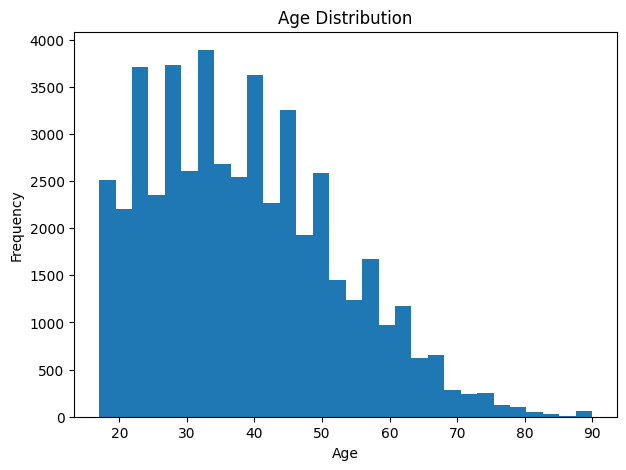

In [31]:
import matplotlib.pyplot as plt

# Histogram: Age
plt.figure(figsize=(7,5))
plt.hist(df["age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

- The distribution of `age` is right-skewed. Most individuals are between **20–50 years old**, with relatively few older participants above 70.  

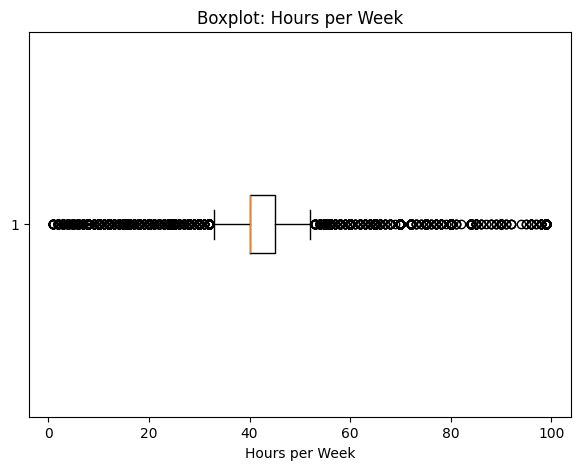

In [32]:
# Boxplot: Hours per Week
plt.figure(figsize=(7,5))
plt.boxplot(df["hours-per-week"].dropna(), vert=False)
plt.title("Boxplot: Hours per Week")
plt.xlabel("Hours per Week")
plt.show()

- The majority of individuals work **around 40 `hours per week`**. However, outliers are present — some report working very low hours (part-time) and others extremely high (up to 99).    

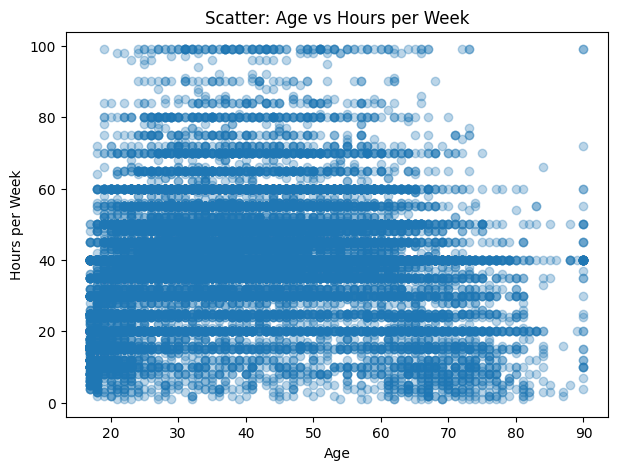

In [33]:
# Scatter: Age vs Hours per Week
plt.figure(figsize=(7,5))
plt.scatter(df["age"], df["hours-per-week"], alpha=0.3)
plt.title("Scatter: Age vs Hours per Week")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()

- There is **no strong correlation** between `age` and `hours-per-week`. Most individuals cluster around 20–60 years old working 35–45 hours. Outliers appear as unusual points (e.g., very old age with extreme hours).

In [34]:
# Frequency counts for categorical attributes
categorical_cols = ["workclass", "education", "marital-status",
                    "occupation", "relationship", "race", "gender",
                    "native-country", "income"]

for col in categorical_cols:
    print(f"\nValue counts for {col}:\n")
    print(df[col].value_counts())


Value counts for workclass:

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Value counts for education:

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Value counts for marital-status:

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dt

**Interpretation: Frequency Counts**  
The frequency counts show that some categories dominate the dataset while others are rare.  
- For example, in *workclass*, the majority are in *Private*.  
- In *education*, categories such as *HS-grad* and *Some-college* occur most frequently, while *Preschool* or *Doctorate* are rare.  
- In *sex*, males appear more often than females.  
- For *native-country*, most individuals are from the United States, while other countries occur very few times.  

This confirms that the dataset has **imbalances across categorical attributes**, which must be considered in preprocessing.


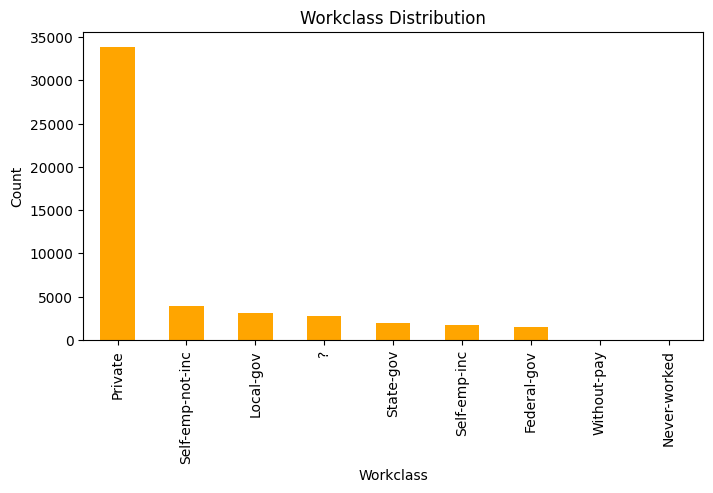

In [35]:
# Bar plot: Workclass
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df["workclass"].value_counts().plot(kind="bar", color="orange")
plt.title("Workclass Distribution")
plt.xlabel("Workclass")
plt.ylabel("Count")
plt.show()


**Interpretation: Workclass Distribution**  
Most individuals work in the *Private* sector. Other categories like *Self-emp-not-inc* and *Local-gov* are less common, while *Never-worked* and *Without-pay* are extremely rare.


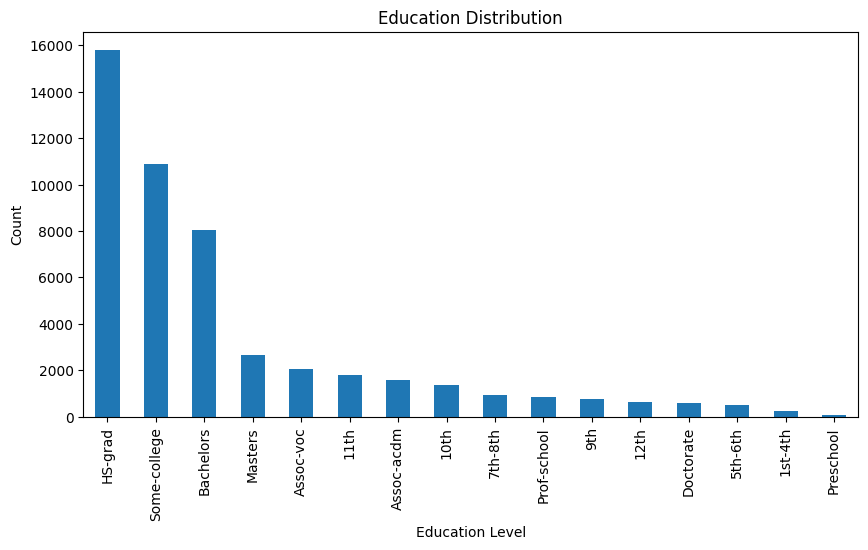

In [36]:

import matplotlib.pyplot as plt

# Bar plot: Education
plt.figure(figsize=(10,5))
df["education"].value_counts().plot(kind="bar")
plt.title("Education Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()


**Interpretation: Education Distribution**  
The plot shows that most individuals fall into the categories *HS-grad*, *Some-college*, and *Bachelors*. Rare categories like *Preschool* and *Doctorate* appear very few times, indicating imbalance in education levels.


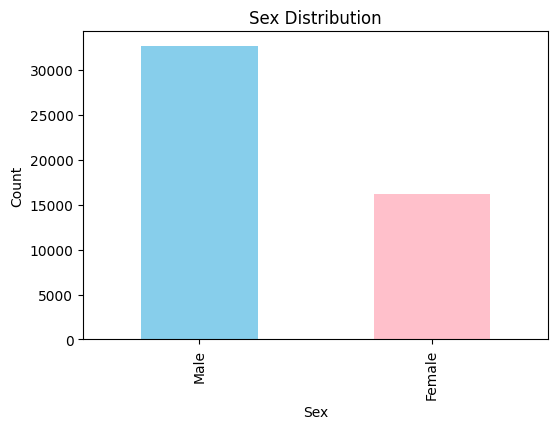

In [37]:
# Bar plot: Sex
plt.figure(figsize=(6,4))
df["gender"].value_counts().plot(kind="bar", color=["skyblue", "pink"])
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

**Interpretation: Sex Distribution**  
The dataset contains more males than females. This imbalance may bias models toward the majority gender.


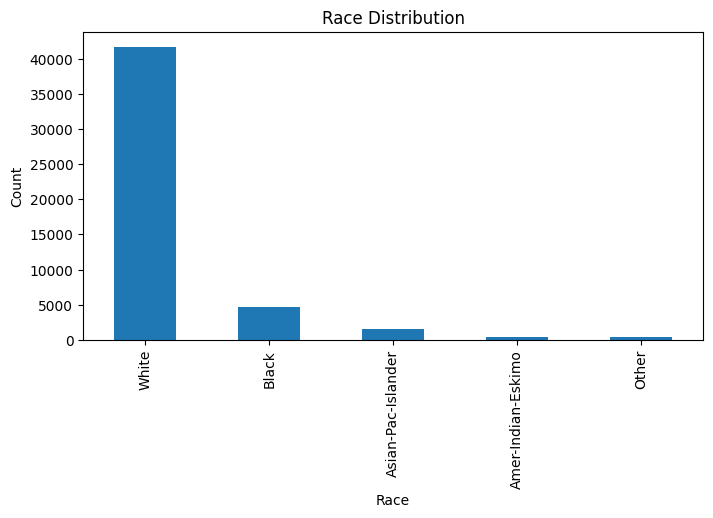

In [38]:
# Bar plot: Race
plt.figure(figsize=(8,4))
df["race"].value_counts().plot(kind="bar")
plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.show()


**Interpretation: Race Distribution**  
The majority of individuals are *White*, followed by *Black*. Other races such as *Asian-Pac-Islander* and *Amer-Indian-Eskimo* appear less frequently, showing race imbalance.


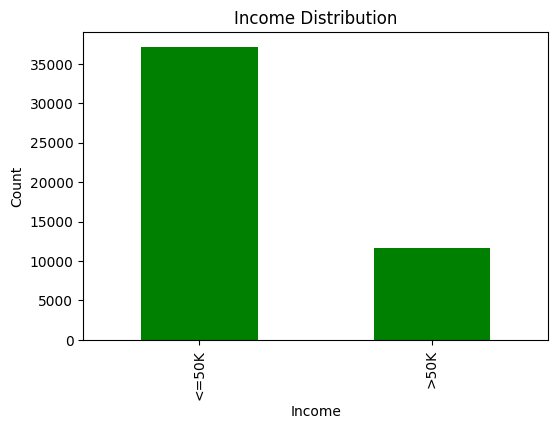

In [39]:
# Class label distribution (Income)
plt.figure(figsize=(6,4))
df["income"].value_counts().plot(kind="bar", color="green")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()


**Interpretation: Income Distribution**  
Most individuals have income `<=50K`, while fewer individuals earn `>50K`. This imbalance in the target variable may require preprocessing such as resampling.


Data Cleaning & Transformation

In [40]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

Replace uknown values "?" with Nan

In [41]:
df = df.replace("?", pd.NA)

Fill missing value

In [42]:
cols_with_missing = ["workclass", "occupation", "native-country"]

In [43]:
for col in cols_with_missing:
  mode_value = df[col].mode()[0]
  df[col] = df[col].fillna(mode_value)

Converted gender into numeric.

In [44]:
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])

In [45]:
df = pd.get_dummies(df, columns=["workclass", "education", "marital-status"] ,drop_first=True)

Transformed categorical columns (workclass, education, marital-status) into binary.

In [46]:
numeric_cols = ["age", "hours-per-week", "capital-gain", "capital-loss"]
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [47]:
df.to_csv("Preprocessed_step3.csv", index=False)

Saved the cleaned version ' Preprocessed_dataset.csv ' for the next phase.

In [48]:
print("Perview of the dataset after preprocessing : ")
print(df.head())
print("\nDataset information after preprocessing : ")
print(df.info())

Perview of the dataset after preprocessing : 
        age  fnlwgt  educational-num         occupation relationship   race  \
0  0.109589  226802                7  Machine-op-inspct    Own-child  Black   
1  0.287671   89814                9    Farming-fishing      Husband  White   
2  0.150685  336951               12    Protective-serv      Husband  White   
3  0.369863  160323               10  Machine-op-inspct      Husband  Black   
4  0.013699  103497               10     Prof-specialty    Own-child  White   

   gender  capital-gain  capital-loss  hours-per-week  ... education_Masters  \
0       1      0.000000           0.0        0.397959  ...             False   
1       1      0.000000           0.0        0.500000  ...             False   
2       1      0.000000           0.0        0.397959  ...             False   
3       1      0.076881           0.0        0.397959  ...             False   
4       0      0.000000           0.0        0.295918  ...             False   